In [1]:
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns
from scipy.signal import welch, detrend
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

from darts import TimeSeries
from darts.models import ExponentialSmoothing


/Users/sk/miniforge3/envs/new/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


In [3]:
df = pd.read_csv(r"/Users/sk/Downloads/filled_data 1.csv")
grouped = df.groupby("Station number")
for station_id, g in grouped:
    print(station_id)
    print(g.head())

9225
       Station number    Lat    Long  Alt East/West  Coastal  Year  Month  \
13011            9225  31.92  115.87   25         W        1  1990      1   
13012            9225  31.92  115.87   25         W        1  1990      2   
13013            9225  31.92  115.87   25         W        1  1990      3   
13014            9225  31.92  115.87   25         W        1  1990      4   
13015            9225  31.92  115.87   25         W        1  1990      5   

       rain   sun  Lowest max  Highest min  Log(one plus rain)  
13011  16.4  27.5        20.2         21.3            2.855985  
13012  16.5  24.6        19.9         21.1            2.861926  
13013  16.6  17.9        19.5         20.8            2.867866  
13014  16.7  14.1        19.2         20.6            2.873807  
13015  16.8  10.8        18.9         20.3            2.879748  
13011
       Station number    Lat    Long  Alt East/West  Coastal  Year  Month  \
13445           13011  26.13  126.58  459         W        

Number of rows after differencing: 14329
First 5 rows:
    Station number    Lat    Long  Alt East/West  Coastal  Year  Month  rain  \
5           14015  12.42  130.89   30         W        1  1941      6   8.1   
6           14015  12.42  130.89   30         W        1  1941      7   0.0   
7           14015  12.42  130.89   30         W        1  1941      8   0.0   
8           14015  12.42  130.89   30         W        1  1941      9   0.0   
9           14015  12.42  130.89   30         W        1  1941     10   0.3   

    sun  Lowest max  Highest min  Log(one plus rain)  trend_diff_s  \
5  21.1        26.7         24.2            2.208274           0.2   
6  21.3        27.9         20.6            0.000000           0.2   
7  21.4        26.9         22.8            0.000000           0.1   
8  21.6        28.1         24.1            0.000000           0.2   
9  21.8        29.4         26.4            0.262364           0.2   

   seasonal_diff_s  combined_diff_s  manual_comb

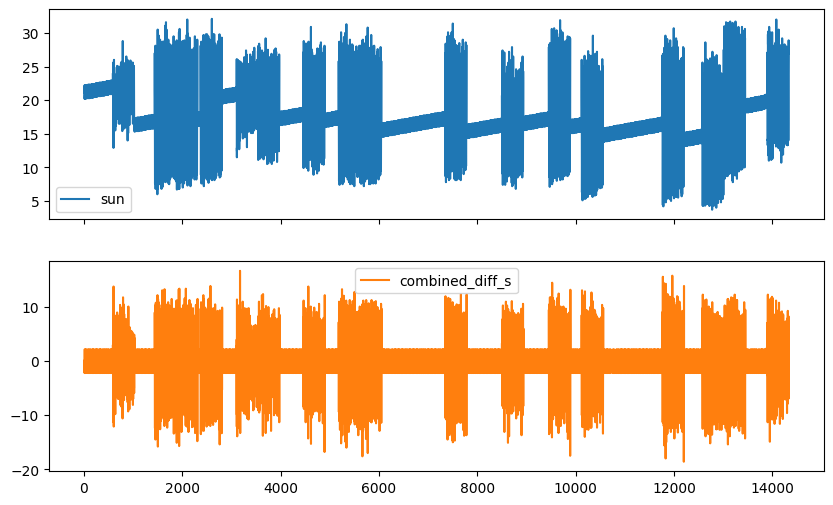

In [4]:
# Example: df with a 'sun' column
# df['sun'] = [your time series data]

m = 4  # seasonal period

# --- 1️⃣ First differencing (remove trend) ---
df['trend_diff_s'] = df['sun'].diff(1)

# --- 2️⃣ Seasonal differencing (remove seasonality) ---
df['seasonal_diff_s'] = df['sun'].diff(m)

# --- 3️⃣ Combined differencing (trend + seasonal) ---
# Correct formula: (1 - B)(1 - B^m)X_t = X_t - X_{t-1} - X_{t-m} + X_{t-m-1}
df['combined_diff_s'] = df['sun'].diff(1).diff(m)

# --- 4️⃣ Optional: manual verification ---
df['manual_combined'] = df['sun'] - df['sun'].shift(1) - df['sun'].shift(m) + df['sun'].shift(m+1)

# Check if combined_diff_s matches manual_combined
if not df['combined_diff_s'].equals(df['manual_combined']):
    print("Warning: combined differencing does not match manual formula!")

# --- 5️⃣ Drop NaN values once at the end ---
df_clean = df.dropna().copy()

# --- 6️⃣ Quick checks ---
print("Number of rows after differencing:", len(df_clean))
print("First 5 rows:\n", df_clean.head())

# Optional: check stationarity visually
import matplotlib.pyplot as plt
df_clean[['sun','combined_diff_s']].plot(subplots=True, figsize=(10,6))
plt.show()

Number of rows after differencing: 14329
   Station number    Lat    Long  Alt East/West  Coastal  Year  Month  rain  \
5           14015  12.42  130.89   30         W        1  1941      6   8.1   
6           14015  12.42  130.89   30         W        1  1941      7   0.0   
7           14015  12.42  130.89   30         W        1  1941      8   0.0   
8           14015  12.42  130.89   30         W        1  1941      9   0.0   
9           14015  12.42  130.89   30         W        1  1941     10   0.3   

    sun  Lowest max  Highest min  Log(one plus rain)  trend_diff_s  \
5  21.1        26.7         24.2            2.208274           0.2   
6  21.3        27.9         20.6            0.000000           0.2   
7  21.4        26.9         22.8            0.000000           0.1   
8  21.6        28.1         24.1            0.000000           0.2   
9  21.8        29.4         26.4            0.262364           0.2   

   seasonal_diff_s  combined_diff_s  manual_combined  
5       

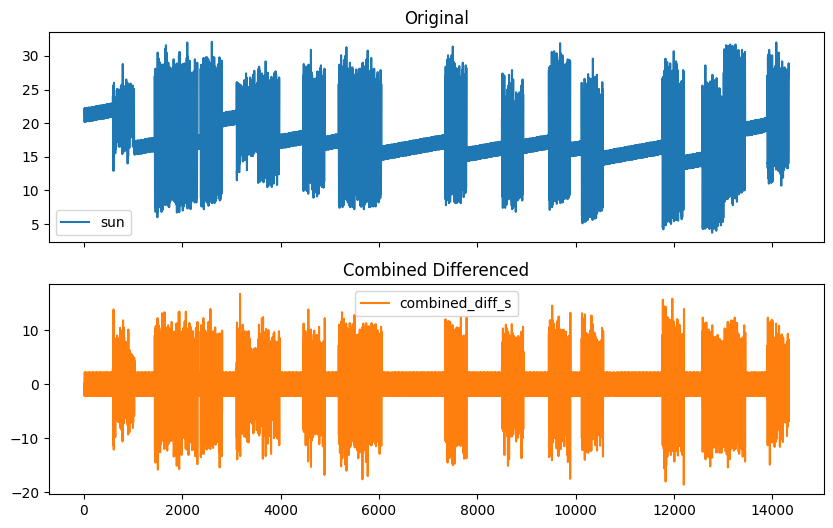

In [5]:
# Example: df with a 'sun' column
# df['sun'] = [your time series data]

m = 4  # seasonal period

# --- 1️⃣ First differencing (trend) ---
df['trend_diff_s'] = df['sun'] - df['sun'].shift(1)

# --- 2️⃣ Seasonal differencing (seasonality) ---
df['seasonal_diff_s'] = df['sun'] - df['sun'].shift(m)

# --- 3️⃣ Combined differencing (trend + seasonal) ---
df['combined_diff_s'] = df['sun'] - df['sun'].shift(1) - df['sun'].shift(m) + df['sun'].shift(m + 1)

# --- 4️⃣ Drop NaNs once at the end ---
df_clean = df.dropna().copy()

# --- 5️⃣ Quick checks ---
print("Number of rows after differencing:", len(df_clean))
print(df_clean.head())

# --- 6️⃣ Optional: visualize ---
df_clean[['sun','combined_diff_s']].plot(subplots=True, figsize=(10,6), title=['Original', 'Combined Differenced'])
plt.show()

Number of rows after differencing: 14329
   Station number    Lat    Long  Alt East/West  Coastal  Year  Month  rain  \
5           14015  12.42  130.89   30         W        1  1941      6   8.1   
6           14015  12.42  130.89   30         W        1  1941      7   0.0   
7           14015  12.42  130.89   30         W        1  1941      8   0.0   
8           14015  12.42  130.89   30         W        1  1941      9   0.0   
9           14015  12.42  130.89   30         W        1  1941     10   0.3   

    sun  Lowest max  Highest min  Log(one plus rain)  trend_diff_s  \
5  21.1        26.7         24.2            2.208274           0.2   
6  21.3        27.9         20.6            0.000000           0.2   
7  21.4        26.9         22.8            0.000000           0.1   
8  21.6        28.1         24.1            0.000000           0.2   
9  21.8        29.4         26.4            0.262364           0.2   

   seasonal_diff_s  combined_diff_s  manual_combined  trend_dif

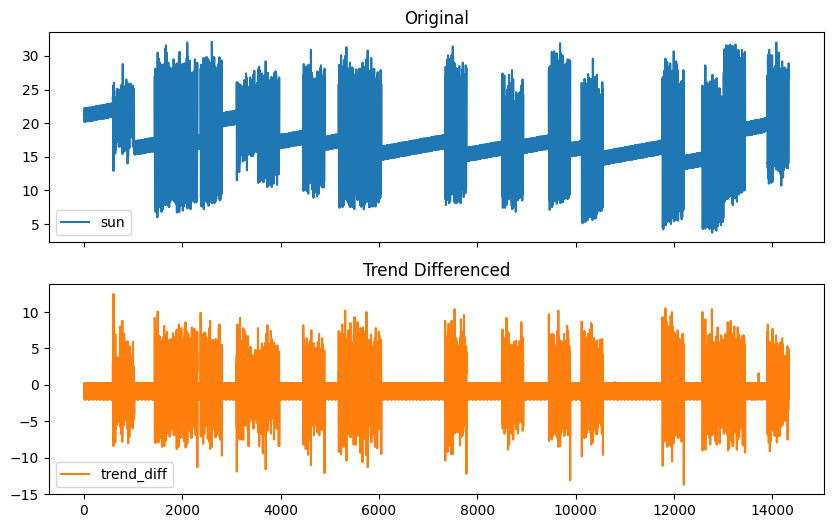

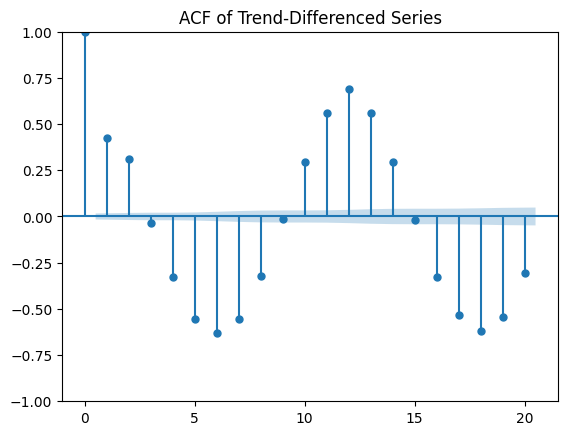

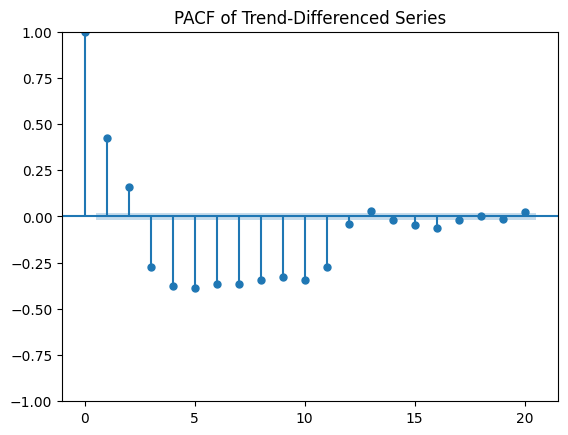

In [6]:

# Example: df with a 'sun' column
# df['sun'] = [your time series data]

# --- 1️⃣ First differencing to remove trend ---
df['trend_diff'] = df['sun'] - df['sun'].shift(1)

# --- 2️⃣ Drop the first NaN ---
df_clean = df.dropna().copy()

# --- 3️⃣ Quick checks ---
print("Number of rows after differencing:", len(df_clean))
print(df_clean.head())

# --- 4️⃣ Optional: visualize original vs differenced ---
df_clean[['sun', 'trend_diff']].plot(subplots=True, figsize=(10,6), title=['Original', 'Trend Differenced'])
plt.show()

# --- 5️⃣ Optional: check ACF/PACF ---
plot_acf(df_clean['trend_diff'], lags=20, title='ACF of Trend-Differenced Series')
plot_pacf(df_clean['trend_diff'], lags=20, title='PACF of Trend-Differenced Series')
plt.show()

In [7]:
# Assume m is the seasonal period
m = 4  # example: quarterly seasonality

# Seasonal differencing
df['seasonal_diff'] = df['trend_diff'] - df['trend_diff'].shift(m)

# Drop the first m NaNs caused by the shift
df_clean = df.dropna().copy()

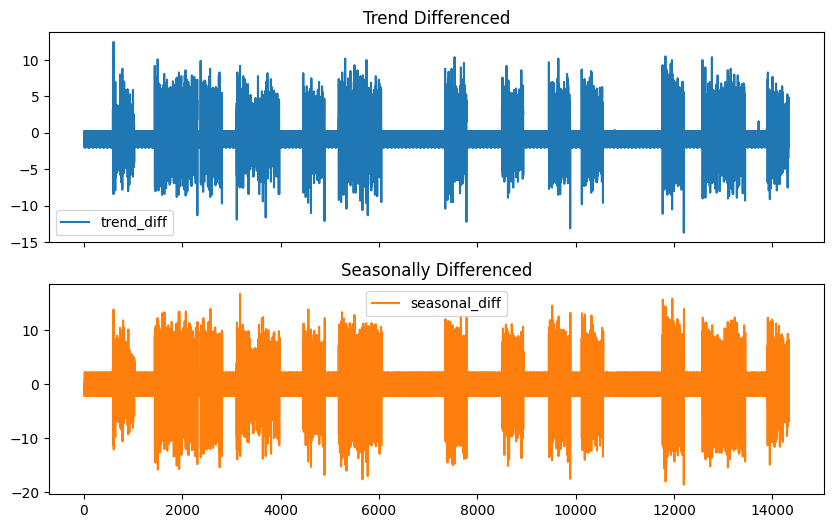

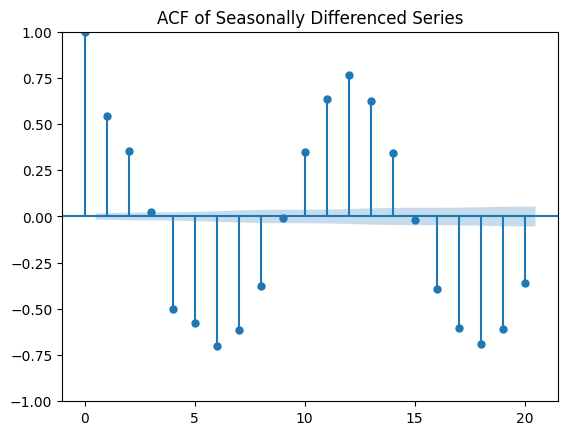

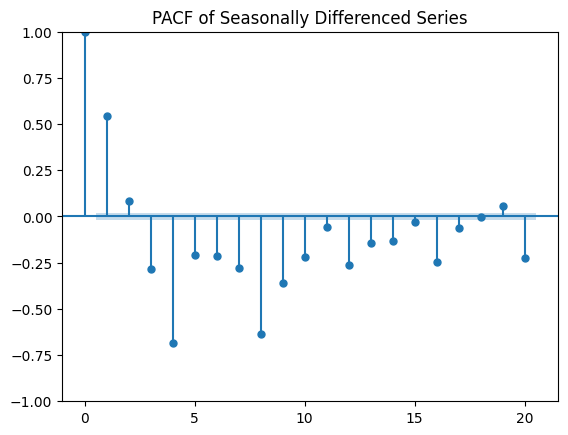

In [8]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Visualize
df_clean[['trend_diff', 'seasonal_diff']].plot(subplots=True, figsize=(10,6), title=['Trend Differenced', 'Seasonally Differenced'])
plt.show()

# ACF/PACF to check for remaining patterns
plot_acf(df_clean['seasonal_diff'], lags=20, title='ACF of Seasonally Differenced Series')
plot_pacf(df_clean['seasonal_diff'], lags=20, title='PACF of Seasonally Differenced Series')
plt.show()

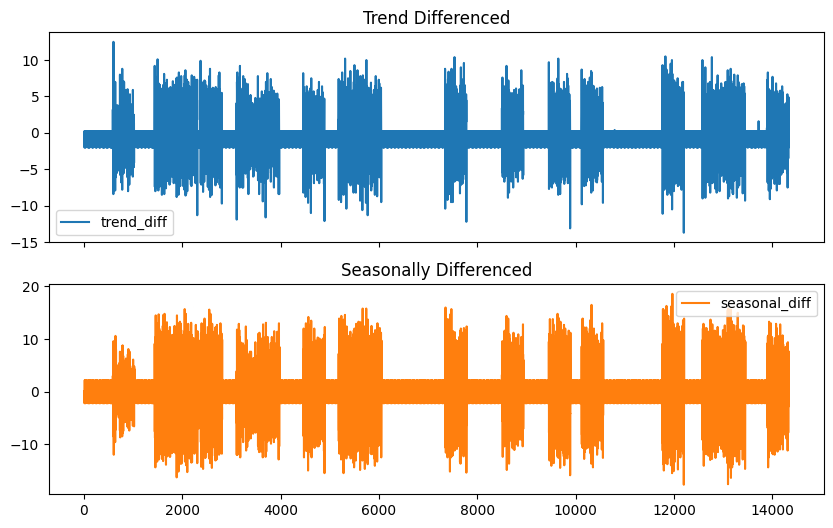

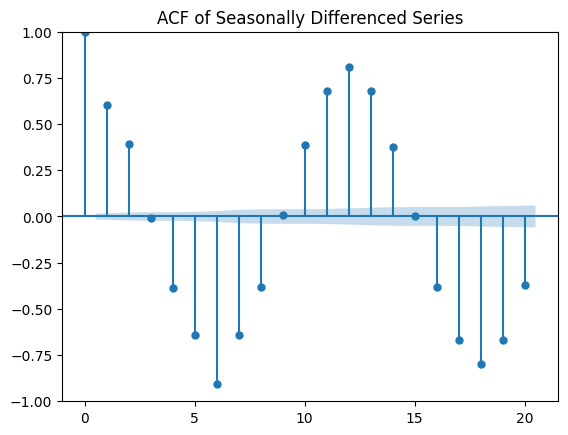

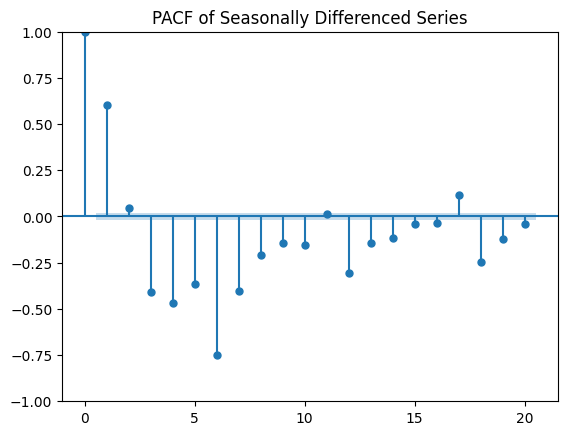

In [12]:
m = 6 # seasonal period

df['trend_diff'] = df['sun'] - df['sun'].shift(1)
df['seasonal_diff'] = df['trend_diff'] - df['trend_diff'].shift(m)
df_clean = df.dropna().copy()

# Visualize
df_clean[['trend_diff', 'seasonal_diff']].plot(subplots=True, figsize=(10,6), title=['Trend Differenced', 'Seasonally Differenced'])
plt.show()

# ACF/PACF to check for remaining patterns
plot_acf(df_clean['seasonal_diff'], lags=20, title='ACF of Seasonally Differenced Series')
plot_pacf(df_clean['seasonal_diff'], lags=20, title='PACF of Seasonally Differenced Series')
plt.show()